# 🚀 TorchMPC + learned dynamics (Transformer) для B747 — tracking step по θ

Этот ноутбук показывает end-to-end пайплайн управления для `LinearLongitudinalB747-v0` с learned-dynamics моделью **Transformer**:

1. **Создаём среду B747** и задаём опорный сигнал **ступенькой по θ (pitch)**.
2. **Собираем датасет переходов** \((x_t, u_t) \to x_{t+1}\) с помощью `TorchMPCAgent.collect_data(exploration="signals")`.
3. **Обучаем модель динамики** (TransformerDynamicsModel) внутри `TorchMPCAgent.train_dynamics()`.
4. **Делаем MPC rollout** через `agent.select_action()`.
5. **Оцениваем качество** и через `ControlBenchmark`.

> **Единицы измерения (важно):** среда B747 ожидает **действие в градусах**, а внутренняя линейная модель работает в **радианах**. Внутри `TorchMPCAgent` мы работаем в **радианах**, а на вход `env.step()` конвертируем в **градусы** через адаптеры.

> **Про Transformer в этом примере:** используем простой `TransformerEncoder` поверх входа `concat([x,u])` (то есть **seq_len=1**, без явной истории).


In [ ]:
# 📚 Импорт библиотек

import numpy as np
import gymnasium as gym
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from tensoraerospace.signals.standart import unit_step
from tensoraerospace.agent.mpc import (
    MPCAgent,
    MPCConstraints,
    MPCStepResponseExtraCostConfig,
    MPCTrackingExtraCostConfig,
    MPCWeights,
    TransformerDynamicsModel,
)
from tensoraerospace.benchmark import ControlBenchmark
from tensoraerospace.benchmark.function import find_step_function


In [ ]:
# ⚙️ Конфигурация

np.random.seed(0)
torch.manual_seed(0)

# Симуляция
DT = 0.1
TN = 20.0
N_STEPS = int(TN / DT) + 1
T = np.arange(N_STEPS, dtype=np.float32) * DT

# Ступенчатый референс theta
REF_STEP_DEG = 5.0
REF_STEP_TIME_S = 5.0

# Сбор датасета (исследовательское управление)
COLLECT_EPISODES = 1500

# Амплитуда исследовательского управления (в единицах среды: deg для LinearLongitudinalB747)
ACTION_RANGE_DEG = 25.0

# Transformer hyperparams (simple, seq_len=1)
D_MODEL = 64
N_HEAD = 4
N_LAYERS = 2
FF_DIM = 256
DROPOUT = 0.1

# Обучение dynamics
EPOCHS = 120
BATCH_SIZE = 512
LR = 1e-4

# MPC
# (HORIZON * MPC_ITERS) напрямую влияет на скорость rollout.
HORIZON = 20
MPC_ITERS = 60
MPC_LR = 0.02

# MPC speed knobs
MPC_TRACK_BEST = True
MPC_BEST_CHECK_EVERY = 5
MPC_COMPILE_DYNAMICS = True  # включаем только на CUDA (см. agent init)
MPC_COMPILE_MODE = "reduce-overhead"

# Лимит скорости руля (deg/step)
DU_MAX_DEG = 3.0

# Веса MPC (в единицах модели: u,w [м/с], q,theta [рад])
W_U = 0.0
W_W = 0.0
W_Q = 0.2
W_THETA = 2000.0
W_ACTION = 0.01
W_DU = 5.0
TERMINAL_WEIGHT = 10.0

# --- step_response penalties (как в ImprovedB747Env) ---
OVERSHOOT_LIMIT_DEG = 0.05
SETTLE_BAND_DEG = 0.10
SETTLE_TIME_TARGET_S = 1.0

REF_CHANGE_THRESHOLD_DEG = 0.10
MIN_STEP_AMP_DEG = 0.50
Q_SETTLE_DEG_S = 0.25

W_OVERSHOOT = 8_000.0
W_TIME = 800.0
W_SETTLE = 8_000.0
W_SSE_STEADY = 40_000.0
W_OSC = 500.0
W_JERK = 50.0

W_DU_STEADY = 80.0
W_JERK_STEADY = 800.0

print("DT=", DT, "TN=", TN, "N_STEPS=", N_STEPS)


DT= 0.1 TN= 20.0 N_STEPS= 201


In [3]:
# 🛩️ Среда B747 + опорный сигнал (ступенька)

reference_signal = unit_step(
    tp=T,
    degree=float(REF_STEP_DEG),
    time_step=float(REF_STEP_TIME_S),
    output_rad=True,
).reshape(1, -1)

env = gym.make(
    "LinearLongitudinalB747-v0",
    number_time_steps=N_STEPS,
    initial_state=np.array([[0.0], [0.0], [0.0], [0.0]], dtype=np.float32),
    reference_signal=reference_signal,
    dt=float(DT),
)


In [ ]:
# 📦 TorchMPCAgent + Transformer dynamics + сбор датасета


def pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = pick_device()
print("DEVICE:", DEVICE)


def obs_to_state(env, obs) -> np.ndarray:
    _ = obs
    return np.asarray(env.unwrapped.model.xt, dtype=np.float32).reshape(-1)


def action_from_env(a_env_deg: np.ndarray) -> np.ndarray:
    a_env_deg = np.asarray(a_env_deg, dtype=np.float32).reshape(-1)
    return np.deg2rad(a_env_deg).astype(np.float32)


def action_to_env(u_rad: np.ndarray) -> np.ndarray:
    u_rad = np.asarray(u_rad, dtype=np.float32).reshape(-1)
    return np.rad2deg(u_rad).astype(np.float32)


# Ограничения MPC в радианах (внутренние единицы модели)
_env_u_max_deg = float(np.asarray(env.action_space.high).reshape(-1)[0])
u_lim = float(np.deg2rad(_env_u_max_deg))
du_max = float(np.deg2rad(float(DU_MAX_DEG)))

weights = MPCWeights(
    Q_diag=np.array([W_U, W_W, W_Q, W_THETA], dtype=np.float32),
    R_diag=np.array([W_ACTION], dtype=np.float32),
    S_diag=np.array([W_DU], dtype=np.float32),
    terminal_weight=float(TERMINAL_WEIGHT),
)
constraints = MPCConstraints(
    u_min=np.array([-u_lim], dtype=np.float32),
    u_max=np.array([u_lim], dtype=np.float32),
    du_min=np.array([-du_max], dtype=np.float32),
    du_max=np.array([du_max], dtype=np.float32),
)

MAX_STEPS_COLLECT = int(env.unwrapped.number_time_steps - 2)
MEMORY_CAPACITY = int(COLLECT_EPISODES * MAX_STEPS_COLLECT + 1000)

SIGNAL_KINDS = [
    "random_steps",
    "unit_step",
    "multi_step",
    "ramp",
    "sinusoid",
    "multisine",
    "chirp",
    "square_wave",
    "triangular_wave",
    "sawtooth",
    "doublet",
    "pulse",
    "gaussian_pulse",
    "exponential",
    "damped_sinusoid",
]

TRACKING_TYPE = "step_response"

tracking_cfg = MPCTrackingExtraCostConfig(
    w_du=0.0,
    w_jerk=0.0,
)

step_cfg = MPCStepResponseExtraCostConfig.from_degrees(
    tracked_idx=3,  # theta
    rate_idx=2,  # q
    dt=float(DT),
    ref_change_threshold_deg=float(REF_CHANGE_THRESHOLD_DEG),
    min_step_amp_deg=float(MIN_STEP_AMP_DEG),
    overshoot_limit_deg=float(OVERSHOOT_LIMIT_DEG),
    settle_band_deg=float(SETTLE_BAND_DEG),
    settle_time_target_s=float(SETTLE_TIME_TARGET_S),
    rate_settle_deg_s=float(Q_SETTLE_DEG_S),
    w_overshoot=float(W_OVERSHOOT),
    w_time=float(W_TIME),
    w_settle=float(W_SETTLE),
    w_sse_steady=float(W_SSE_STEADY),
    w_osc=float(W_OSC),
    w_jerk=float(W_JERK),
    w_du_steady=float(W_DU_STEADY),
    w_jerk_steady=float(W_JERK_STEADY),
)

transformer_model = TransformerDynamicsModel(
    input_dim=4 + 1,
    output_dim=4,
    d_model=int(D_MODEL),
    nhead=int(N_HEAD),
    num_encoder_layers=int(N_LAYERS),
    dim_feedforward=int(FF_DIM),
    dropout=float(DROPOUT),
    seq_len=1,
)

print("u_lim(deg)=", float(np.rad2deg(u_lim)), "du_max(deg/step)=", float(DU_MAX_DEG))

# Приводим ACTION_RANGE_DEG к доле от границ action_space (в единицах env)
_env_u_max = float(_env_u_max_deg)
action_amp_frac = float(np.clip(float(ACTION_RANGE_DEG) / max(1e-6, _env_u_max), 1e-3, 1.0))
print("action_amp_frac:", action_amp_frac)

agent = MPCAgent(
    env,
    state_dim=4,
    action_dim=1,
    horizon=int(HORIZON),
    weights=weights,
    constraints=constraints,
    tracking_type=TRACKING_TYPE,
    tracking_config=tracking_cfg,
    step_response_config=step_cfg,
    extra_cost_fn=None,
    iters=int(MPC_ITERS),
    mpc_lr=float(MPC_LR),
    mpc_optimizer="adam",
    warm_start=True,
    mpc_track_best=bool(MPC_TRACK_BEST),
    mpc_best_check_every=int(MPC_BEST_CHECK_EVERY),
    mpc_compile_dynamics=bool(MPC_COMPILE_DYNAMICS and DEVICE == "cuda"),
    mpc_compile_mode=str(MPC_COMPILE_MODE),
    model=transformer_model,
    model_predict_delta=True,
    normalize=True,
    dynamics_lr=float(LR),
    memory_capacity=int(MEMORY_CAPACITY),
    obs_to_state=obs_to_state,
    action_to_env=action_to_env,
    action_from_env=action_from_env,
    device=DEVICE,
    seed=0,
)

print("Collecting transitions (signals)...")
agent.collect_data(
    num_episodes=int(COLLECT_EPISODES),
    max_steps=int(MAX_STEPS_COLLECT),
    exploration="signals",
    signal_kinds=SIGNAL_KINDS,
    dt=float(DT),
    action_amplitude_frac=action_amp_frac,
)

print("Replay size:", len(agent.memory))


DEVICE: mps
u_lim(deg)= 25.0 du_max(deg/step)= 3.0
action_amp_frac: 1.0


Collect episodes:   0%|          | 0/1500 [00:00<?, ?it/s]/Users/asmazaev/TensorAeroSpace-Origin/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/Users/asmazaev/TensorAeroSpace-Origin/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
Collect episodes: 100%|██████████| 1500/1500 [00:16<00:00, 90.86it/s] 

Replay size: 297000


In [5]:
# 🧠 Обучение dynamics внутри TorchMPCAgent

metrics = agent.train_dynamics(
    epochs=int(EPOCHS),
    batch_size=int(BATCH_SIZE),
    loss="mse",
)

print("train metrics:", metrics)

# Быстрый sanity-check 1-step предсказания
s, a, _r, ns, _d = agent.memory.sample(batch_size=1)

s_t = torch.as_tensor(s, dtype=torch.float32, device=agent.device).view(1, -1)
a_t = torch.as_tensor(a, dtype=torch.float32, device=agent.device).view(1, -1)

with torch.no_grad():
    ns_pred = agent.mpc.dynamics(s_t, a_t)

print("x:", s.reshape(-1))
print("u(rad):", a.reshape(-1))
print("x_next true:", ns.reshape(-1))
print("x_next pred:", ns_pred.detach().cpu().numpy().reshape(-1))
print("MPC device:", agent.device)


Train dynamics: 100%|██████████| 69600/69600 [18:18<00:00, 63.37step/s, loss=1.57e-5] 


train metrics: {'loss': 1.5660209835343646e-05}
x: [-5.7322961e-01  7.9872233e-01  6.7394110e-04  4.9440223e-03]
u(rad): [0.09293211]
x_next true: [-0.57652515  0.61707073 -0.0101435   0.00446617]
x_next pred: [-0.5762733   0.62124735 -0.01016148  0.00448737]
MPC device: mps


In [6]:
# 🎛️ Tracking mode внутри TorchMPCAgent

ref_change_threshold_rad = float(np.deg2rad(float(REF_CHANGE_THRESHOLD_DEG)))

agent.set_tracking_type(
    TRACKING_TYPE,
    tracking_config=tracking_cfg,
    step_response_config=step_cfg,
)

print(
    "tracking_type=",
    agent.tracking_type,
    "u_lim(deg)=",
    float(_env_u_max_deg),
    "du_max(deg/step)=",
    float(DU_MAX_DEG),
)


tracking_type= step_response u_lim(deg)= 25.0 du_max(deg/step)= 3.0


In [7]:
# 🎮 Rollout MPC в среде (TorchMPCAgent: Transformer dynamics + MPC)

_ = env.reset()
agent.reset()

hist_theta_deg = []
hist_ref_deg = []
hist_u_deg = []

max_steps = int(env.unwrapped.number_time_steps - 2)
ref_theta_rad = np.asarray(env.unwrapped.reference_signal, dtype=np.float32).reshape(1, -1)[0]

# Чтобы не было preview референса — сегментный подход (baseline/target)
seg_baseline = float(ref_theta_rad[0])
seg_target = float(ref_theta_rad[0])

for _ in tqdm(range(max_steps), desc="MPC rollout (agent)"):
    k = int(env.unwrapped.current_step)

    # внутреннее состояние (рад)
    x0 = np.asarray(env.unwrapped.model.xt, dtype=np.float32).reshape(-1)

    ref_k = float(ref_theta_rad[min(k, ref_theta_rad.shape[0] - 1)])
    if abs(ref_k - seg_target) > float(ref_change_threshold_rad):
        seg_baseline = float(seg_target)
        seg_target = float(ref_k)

    theta_ref_h = np.full((int(HORIZON) + 1,), seg_target, dtype=np.float32)
    theta_ref_h[0] = seg_baseline

    x_ref = np.zeros((int(HORIZON) + 1, 4), dtype=np.float32)
    x_ref[:, 3] = theta_ref_h

    # action в градусах (как ожидает env)
    action = agent.select_action(x0, x_ref=x_ref).astype(np.float32)

    _obs, reward, terminated, truncated, _info = env.step(action)

    k1 = int(env.unwrapped.current_step)
    theta_deg = float(np.rad2deg(np.asarray(env.unwrapped.model.xt).reshape(-1)[3]))
    ref_deg = float(np.rad2deg(ref_theta_rad[min(k1, ref_theta_rad.shape[0] - 1)]))

    hist_theta_deg.append(theta_deg)
    hist_ref_deg.append(ref_deg)
    hist_u_deg.append(float(action.reshape(-1)[0]))

    if terminated or truncated:
        break

print("steps:", len(hist_theta_deg), "last reward:", reward)


MPC rollout (agent):   0%|          | 0/199 [00:00<?, ?it/s]

steps: 199 last reward: -94552.2835383925


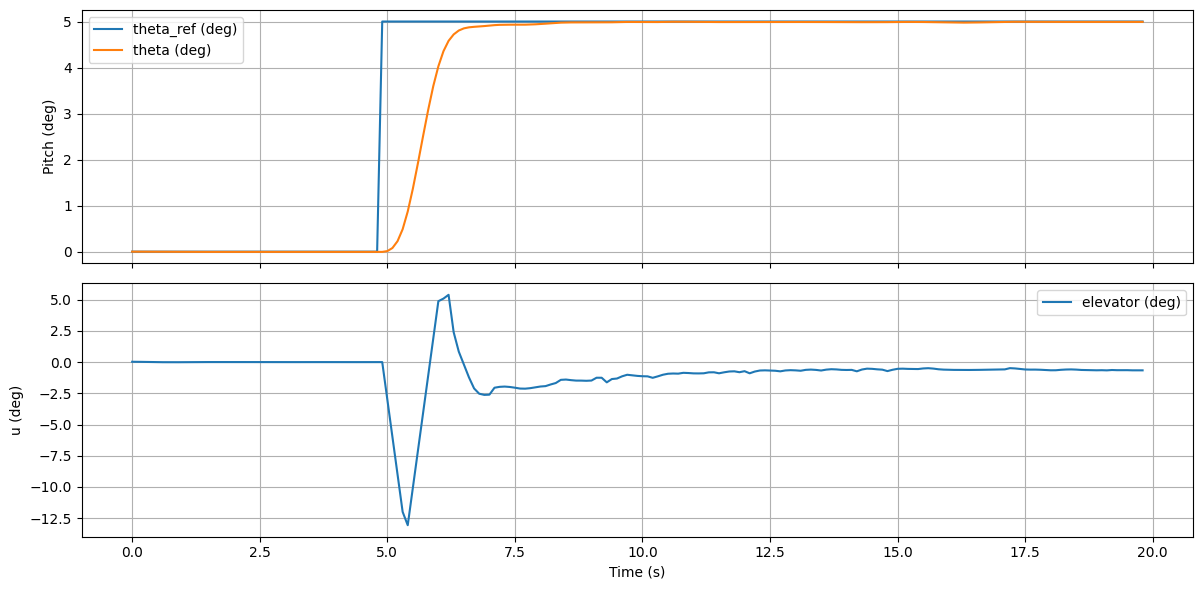


📊 ControlBenchmark metrics
        damping_degree: -0.0011205131886526942
                   iae: 46.212432861328125
                   ise: 170.65805053710938
                  itae: 34.868559384346014
     maximum_deviation: 5.005065441131592
     oscillation_count: 6
             overshoot: -0.09932519169524312
             peak_time: 2.5
     performance_index: 82.23050900692121
             rise_time: 0.8
         settling_time: 1.5
          static_error: 0.008643627166748047
    steady_state_value: 4.999999523162842


╔══════════════════════════════════════════════════════════════╗
║                    ОТЧЕТ О КАЧЕСТВЕ УПРАВЛЕНИЯ               ║
╠══════════════════════════════════════════════════════════════╣
║ Система: B747 TorchMPCAgent (Transformer dynamics)       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ 📊 ОСНОВНЫЕ ПОКАЗАТЕЛИ КАЧЕСТВА:                            ║
║                  

In [8]:
# 📈 Результаты: графики + step metrics + ControlBenchmark

hist_theta_deg = np.asarray(hist_theta_deg, dtype=np.float32)
hist_ref_deg = np.asarray(hist_ref_deg, dtype=np.float32)
hist_u_deg = np.asarray(hist_u_deg, dtype=np.float32)

t_plot = np.arange(hist_theta_deg.size, dtype=np.float32) * float(DT)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t_plot, hist_ref_deg, label="theta_ref (deg)")
axes[0].plot(t_plot, hist_theta_deg, label="theta (deg)")
axes[0].set_ylabel("Pitch (deg)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t_plot, hist_u_deg, label="elevator (deg)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("u (deg)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# --- ControlBenchmark ---
bench = ControlBenchmark()
signal_val = float(hist_ref_deg[0]) if hist_ref_deg.size else 0.0

metrics_bench = bench.becnchmarking_one_step(
    control_signal=hist_ref_deg,
    system_signal=hist_theta_deg,
    signal_val=signal_val,
    dt=float(DT),
)

print("\n" + "=" * 60)
print("📊 ControlBenchmark metrics")
print("=" * 60)
for k in sorted(metrics_bench.keys()):
    print(f"{k:>22s}: {metrics_bench[k]}")

print(
    "\n"
    + bench.generate_report(
        control_signal=hist_ref_deg,
        system_signal=hist_theta_deg,
        signal_val=signal_val,
        dt=float(DT),
        system_name="B747 TorchMPCAgent (Transformer dynamics)",
    )
)

SHOW_BENCHMARK_PLOT = True
if SHOW_BENCHMARK_PLOT and hist_ref_deg.size:
    ctrl_step, _ = find_step_function(hist_ref_deg, hist_theta_deg, signal_val=signal_val)
    tps_step = np.arange(ctrl_step.size, dtype=np.float32) * float(DT)
    bench.plot(
        control_signal=hist_ref_deg,
        system_signal=hist_theta_deg,
        signal_val=signal_val,
        dt=float(DT),
        tps=tps_step,
        title="B747 MPC Step Response (TorchMPCAgent + Transformer)",
    )
